In [ ]:
# ============================================
# TASK 3 - BREAST CANCER DIAGNOSTICS
# Codtech Machine Learning Internship
# Dataset: Breast Cancer Wisconsin Dataset
# Objective: Classify tumors as Malignant or Benign
# ============================================

# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree

In [ ]:
# ============================================
# STEP 1 - LOAD AND EXPLORE THE DATASET
# ============================================

# Load the breast cancer dataset
cancer = load_breast_cancer()

# Convert to pandas dataframe for easy viewing
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['diagnosis'] = cancer.target

# Explore the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDiagnosis Labels:")
print("0 = Malignant (Cancerous)")
print("1 = Benign (Not Cancerous)")
print("\nDiagnosis Distribution:")
print(df['diagnosis'].value_counts())
print(f"\nMalignant cases: {sum(cancer.target == 0)}")
print(f"Benign cases: {sum(cancer.target == 1)}")

Dataset Shape: (569, 31)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst

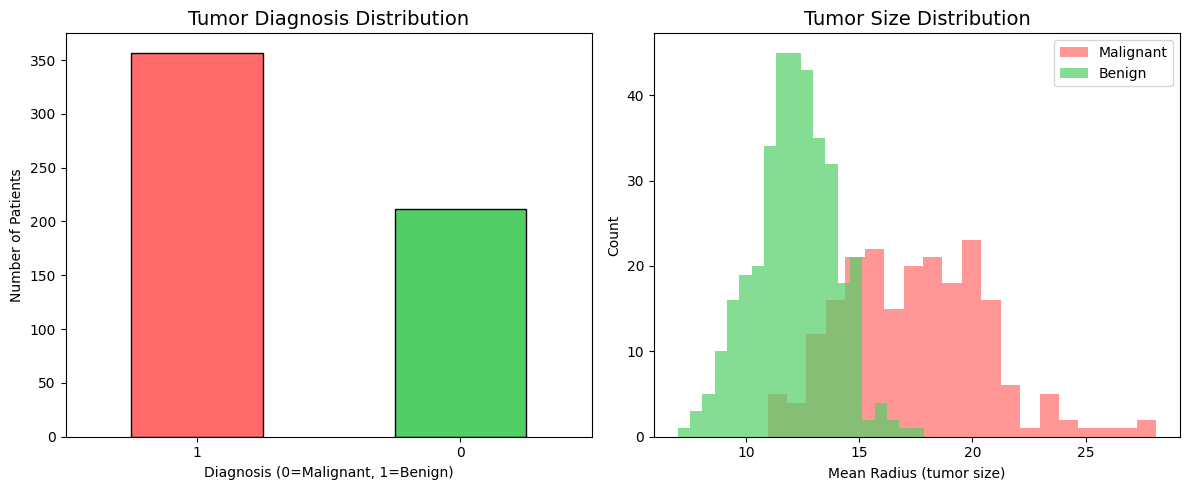

Charts saved!


In [ ]:
# ============================================
# STEP 2 - VISUALIZE THE DATA
# ============================================

# Plot diagnosis distribution
plt.figure(figsize=(12, 5))

# Chart 1 - Count of each diagnosis
plt.subplot(1, 2, 1)
colors = ['#ff6b6b', '#51cf66']
df['diagnosis'].value_counts().plot(kind='bar',
                                     color=colors,
                                     edgecolor='black')
plt.title('Tumor Diagnosis Distribution', fontsize=14)
plt.xlabel('Diagnosis (0=Malignant, 1=Benign)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

# Chart 2 - Feature comparison between malignant and benign
plt.subplot(1, 2, 2)
malignant = df[df['diagnosis'] == 0]['mean radius']
benign = df[df['diagnosis'] == 1]['mean radius']
plt.hist(malignant, alpha=0.7, color='#ff6b6b',
         label='Malignant', bins=20)
plt.hist(benign, alpha=0.7, color='#51cf66',
         label='Benign', bins=20)
plt.title('Tumor Size Distribution', fontsize=14)
plt.xlabel('Mean Radius (tumor size)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.savefig('cancer_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

In [ ]:
# ============================================
# STEP 3 - TRAIN THE MODEL
# ============================================

# Separate features and target
X = cancer.data   # 30 tumor measurements
y = cancer.target # 0=Malignant, 1=Benign

# Split into training and testing
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Create and train Decision Tree model
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {round(accuracy * 100, 2)}%")

# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Malignant', 'Benign']))


Training samples: 455
Testing samples: 114

Model Accuracy: 94.74%

Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        43
      Benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



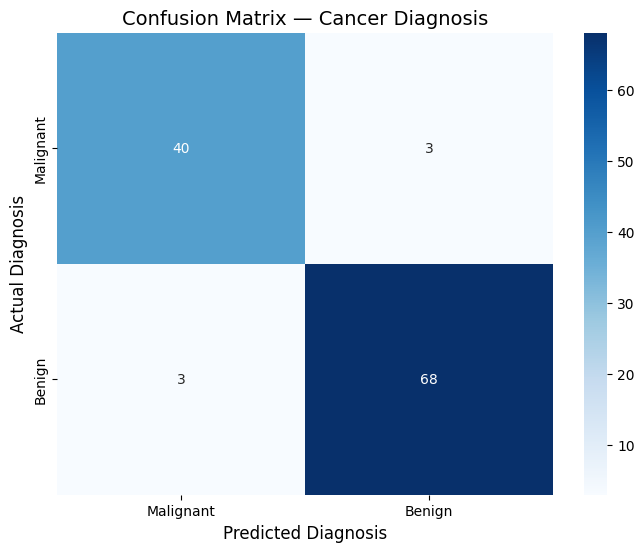

True Negatives  (Malignant correctly identified): 40
False Positives (Benign wrongly called Malignant): 3
False Negatives (Malignant missed!): 3
True Positives  (Benign correctly identified): 68

Most critical: False Negatives = 3
These are cancer cases the model MISSED ⚠️


In [ ]:
# ============================================
# STEP 4 - CONFUSION MATRIX
# ============================================

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,        # show numbers
            fmt='d',           # integer format
            cmap='Blues',      # blue color scheme
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])

plt.title('Confusion Matrix — Cancer Diagnosis', fontsize=14)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.savefig('confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Explain the results
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Malignant correctly identified): {tn}")
print(f"False Positives (Benign wrongly called Malignant): {fp}")
print(f"False Negatives (Malignant missed!): {fn}")
print(f"True Positives  (Benign correctly identified): {tp}")
print(f"\nMost critical: False Negatives = {fn}")
print("These are cancer cases the model MISSED ⚠️")

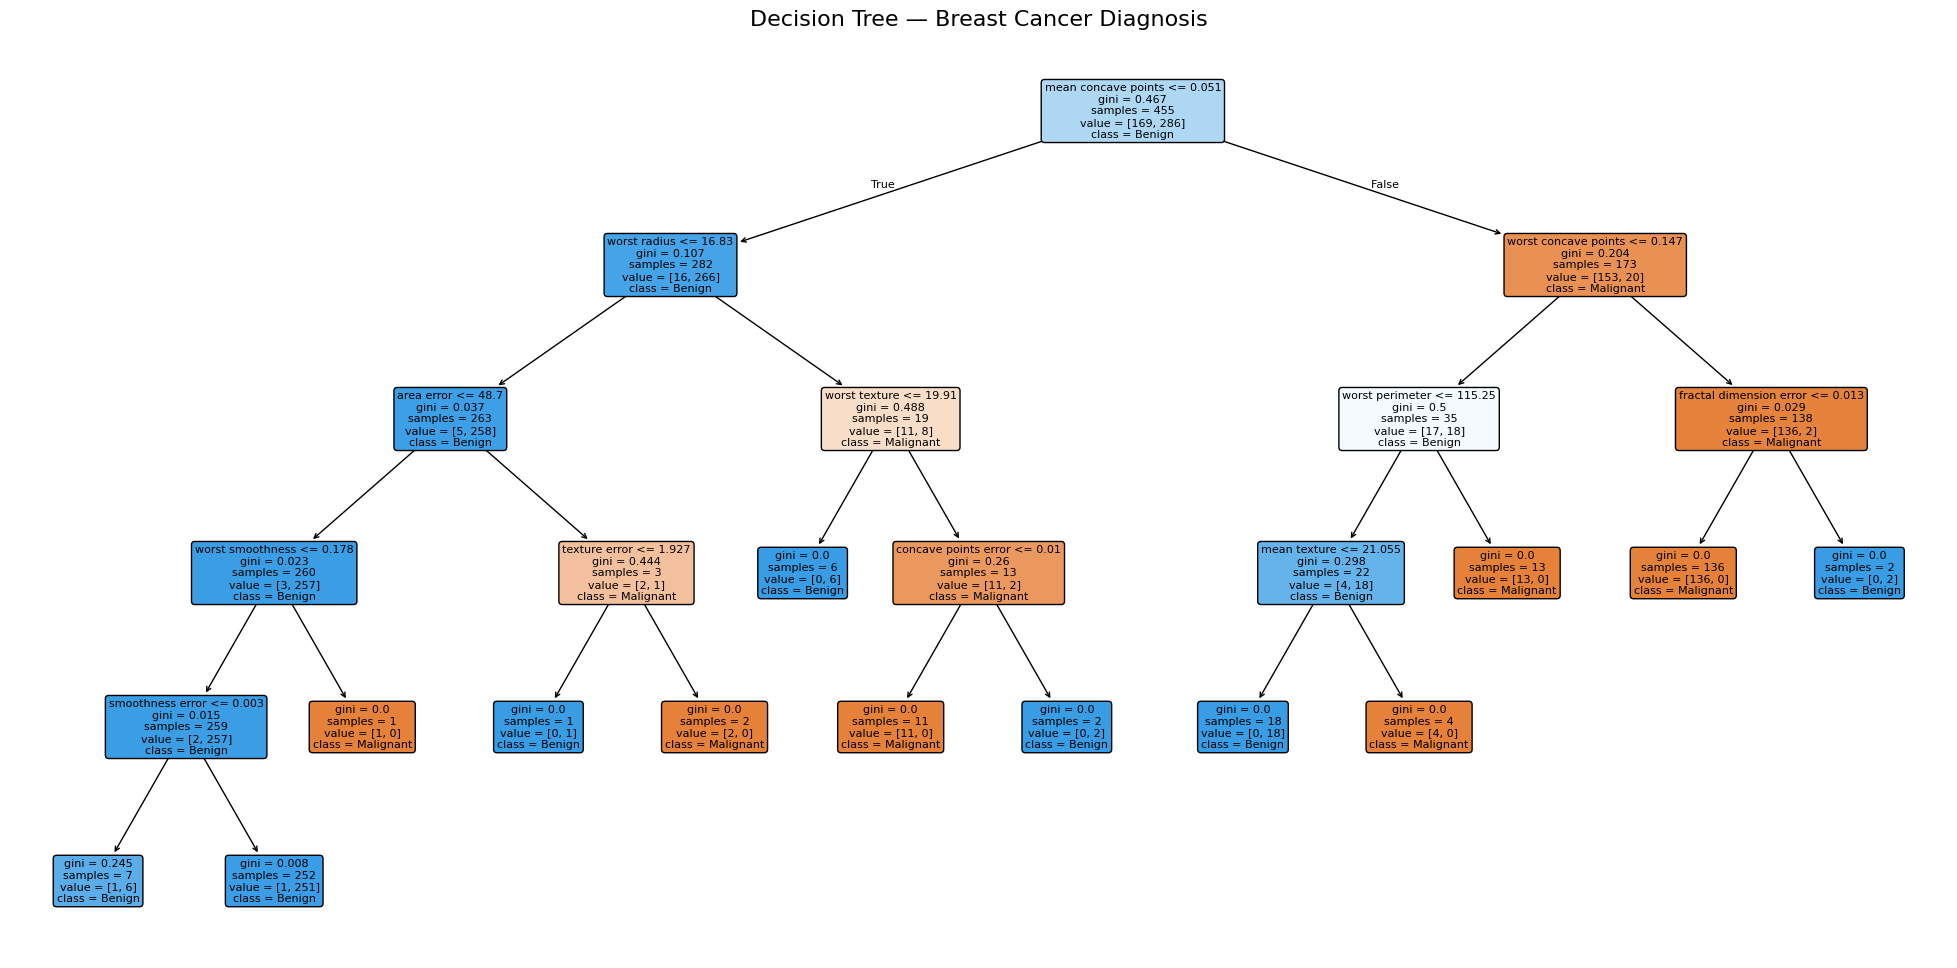

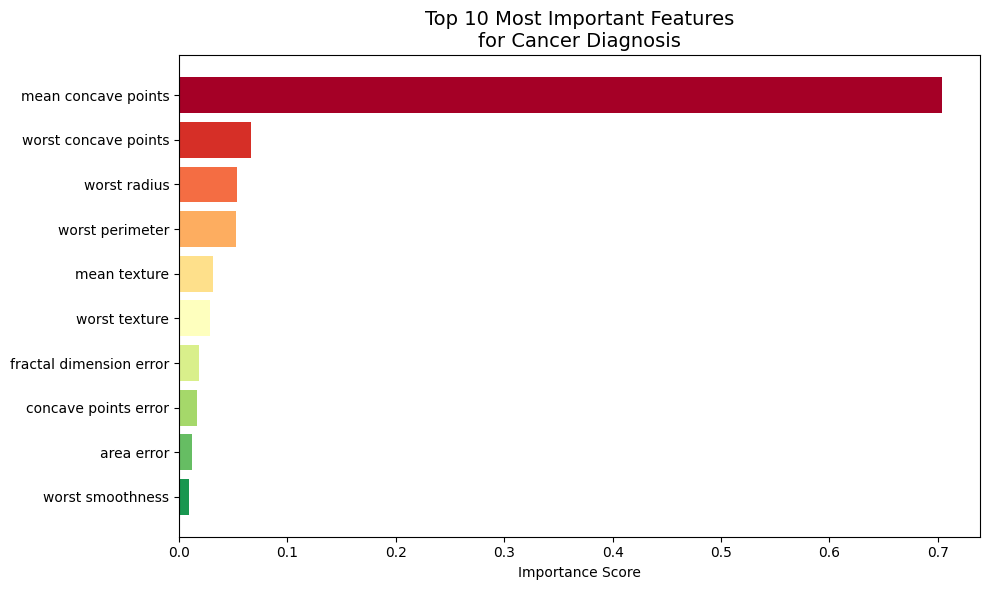


Top 3 most important features:
  mean concave points: 70.4%
  worst concave points: 6.7%
  worst radius: 5.3%

--- Diagnosing a New Patient ---
Diagnosis: MALIGNANT ⚠️
Confidence: 100.0%


In [ ]:
# ============================================
# STEP 5 - DECISION TREE VISUALIZATION
# ============================================

# Visualize the tree
plt.figure(figsize=(25, 12))
tree.plot_tree(model,
               feature_names=cancer.feature_names,
               class_names=['Malignant', 'Benign'],
               filled=True,
               rounded=True,
               fontsize=8)
plt.title("Decision Tree — Breast Cancer Diagnosis",
          fontsize=16)
plt.savefig('cancer_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# STEP 6 - FEATURE IMPORTANCE
# ============================================

# Which measurements matter most for diagnosis?
feature_imp = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(
    [i/10 for i in range(10)])
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'],
         color=colors)
plt.title('Top 10 Most Important Features\nfor Cancer Diagnosis',
          fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
for i, row in feature_imp.head(3).iterrows():
    print(f"  {row['Feature']}: {round(row['Importance']*100, 1)}%")

# ============================================
# STEP 7 - TEST WITH A NEW PATIENT
# ============================================

# Predict for a new patient
print("\n--- Diagnosing a New Patient ---")
new_patient = [cancer.data[0]]  # using first sample as example
prediction = model.predict(new_patient)
probability = model.predict_proba(new_patient)

diagnosis = "BENIGN ✅" if prediction[0] == 1 else "MALIGNANT ⚠️"
print(f"Diagnosis: {diagnosis}")
print(f"Confidence: {round(max(probability[0])*100, 1)}%")

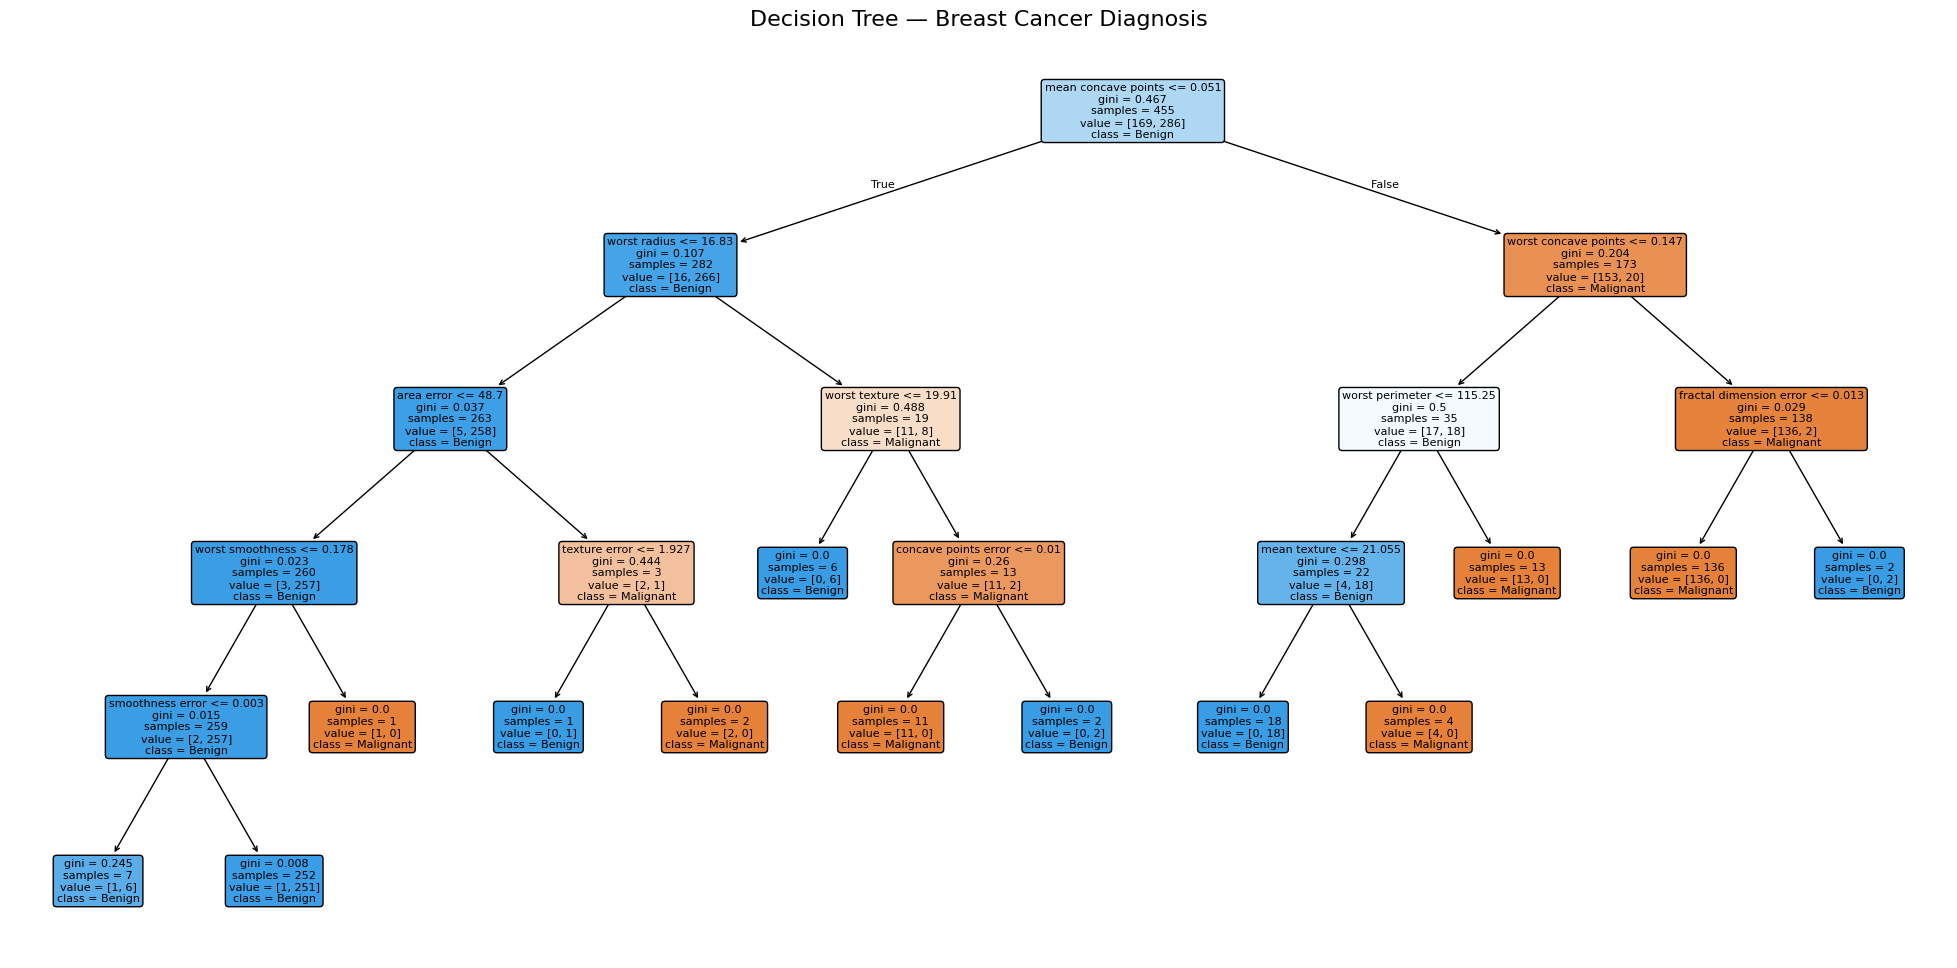

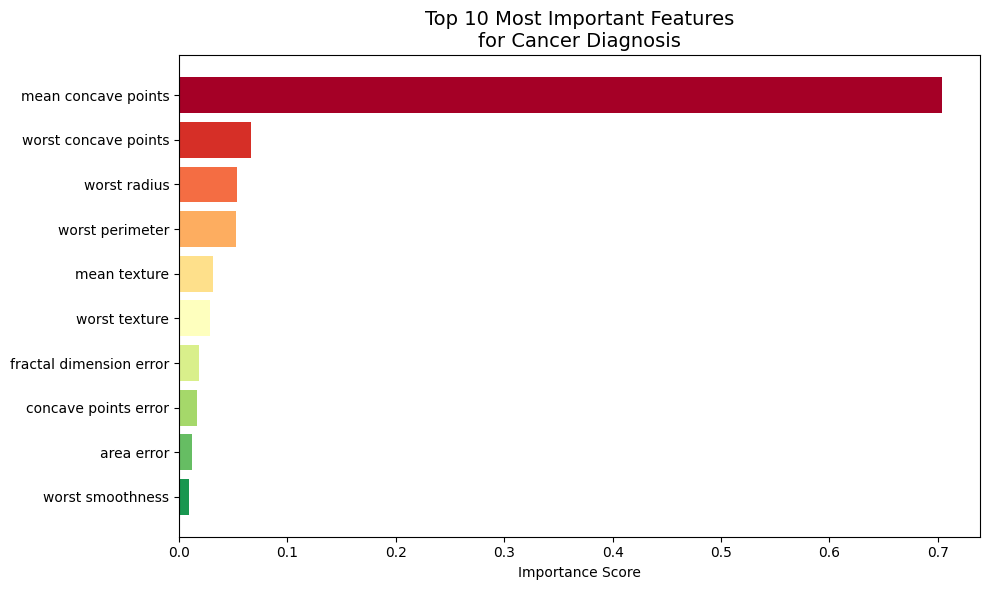


Top 3 most important features:
  mean concave points: 70.4%
  worst concave points: 6.7%
  worst radius: 5.3%

--- Diagnosing a New Patient ---
Diagnosis: MALIGNANT ⚠️
Confidence: 100.0%


In [ ]:
# ============================================
# STEP 5 - DECISION TREE VISUALIZATION
# ============================================

# Visualize the tree
plt.figure(figsize=(25, 12))
tree.plot_tree(model,
               feature_names=cancer.feature_names,
               class_names=['Malignant', 'Benign'],
               filled=True,
               rounded=True,
               fontsize=8)
plt.title("Decision Tree — Breast Cancer Diagnosis",
          fontsize=16)
plt.savefig('cancer_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# STEP 6 - FEATURE IMPORTANCE
# ============================================

# Which measurements matter most for diagnosis?
feature_imp = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(
    [i/10 for i in range(10)])
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'],
         color=colors)
plt.title('Top 10 Most Important Features\nfor Cancer Diagnosis',
          fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
for i, row in feature_imp.head(3).iterrows():
    print(f"  {row['Feature']}: {round(row['Importance']*100, 1)}%")

# ============================================
# STEP 7 - TEST WITH A NEW PATIENT
# ============================================

# Predict for a new patient
print("\n--- Diagnosing a New Patient ---")
new_patient = [cancer.data[0]]  # using first sample as example
prediction = model.predict(new_patient)
probability = model.predict_proba(new_patient)

diagnosis = "BENIGN ✅" if prediction[0] == 1 else "MALIGNANT ⚠️"
print(f"Diagnosis: {diagnosis}")
print(f"Confidence: {round(max(probability[0])*100, 1)}%")

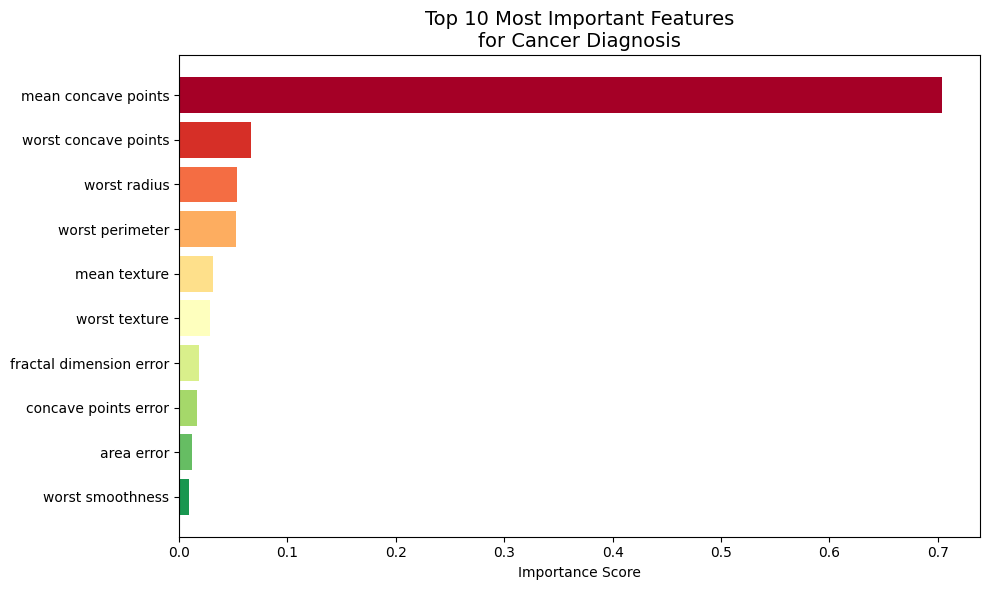


Top 3 most important features for diagnosis:
  mean concave points: 70.4%
  worst concave points: 6.7%
  worst radius: 5.3%

DIAGNOSING A NEW PATIENT
Diagnosis Result: MALIGNANT ⚠️
Model Confidence: 100.0%

TASK 3 COMPLETE — FINAL SUMMARY
Dataset:         Breast Cancer Wisconsin
Total Patients:  569
Features Used:   30
Model:           Decision Tree (max_depth=5)
Train/Test Split: 80% / 20%
Accuracy:        94.74%
False Negatives: 3 (cancer cases missed)
False Positives: 3 (false alarms)

Task 3 Successfully Completed! 🏥


In [ ]:
# STEP 8 - FEATURE IMPORTANCE
# ============================================

# Which tumor measurements matter most?
feature_imp = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn([i/10 for i in range(10)])
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'],
         color=colors)
plt.title('Top 10 Most Important Features\nfor Cancer Diagnosis',
          fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features for diagnosis:")
for idx, row in feature_imp.head(3).iterrows():
    print(f"  {row['Feature']}: {round(row['Importance']*100, 1)}%")
# ============================================
# STEP 9 - DIAGNOSE A NEW PATIENT
# ============================================

print("\n" + "="*50)
print("DIAGNOSING A NEW PATIENT")
print("="*50)

# Using first sample as a new patient example
new_patient = [cancer.data[0]]
prediction = model.predict(new_patient)
probability = model.predict_proba(new_patient)

diagnosis = "BENIGN ✅" if prediction[0] == 1 else "MALIGNANT ⚠️"
confidence = round(max(probability[0]) * 100, 1)

print(f"Diagnosis Result: {diagnosis}")
print(f"Model Confidence: {confidence}%")

# ============================================
# STEP 10 - FINAL SUMMARY
# ============================================

print("\n" + "="*50)
print("TASK 3 COMPLETE — FINAL SUMMARY")
print("="*50)
print(f"Dataset:         Breast Cancer Wisconsin")
print(f"Total Patients:  {df.shape[0]}")
print(f"Features Used:   {df.shape[1]-1}")
print(f"Model:           Decision Tree (max_depth=5)")
print(f"Train/Test Split: 80% / 20%")
print(f"Accuracy:        {round(accuracy * 100, 2)}%")
print(f"False Negatives: {fn} (cancer cases missed)")
print(f"False Positives: {fp} (false alarms)")
print("\nTask 3 Successfully Completed! 🏥")

